# Spotify Hit Predictor: Feature Selection

After cleaning the data in notebook 1, I focused on figuring out which features actually matter for predicting hits.

Main things I explored here:
- Narrowed down to top 10 genres by song count instead of all genres
- Ran VIF to check for multicollinearity, time_signature had some weird behavior I had to investigate
- Tried predicting within a single genre first (pop) as a sanity check  before scaling to all genres

The VIF analysis showed some features were highly correlated so I dropped the ones that weren't adding much.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub # Load data from Kaggles
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score)

from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

import warnings
from statsmodels.stats.outliers_influence import variance_inflation_factor


np.random.seed(42)
pd.set_option('display.max_columns', 50)

## 1. Load the raw data

In [2]:
path = kagglehub.dataset_download("anbudanadithya/spotify-music")
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
csv_path = os.path.join(path, csv_files[0])
df = pd.read_csv(csv_path)
df
print(f'Raw shape: {df.shape}')
print(f'Unique genres: {df["track_genre"].nunique()}')
df.head(3)

100%|██████████| 8.17M/8.17M [00:00<00:00, 64.1MB/s]

Extracting files...


Raw shape: (114000, 21)
Unique genres: 114


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


In [5]:
print(df.columns)

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')


In [ ]:
print('Missing values per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f'\nDuplicate track_ids: {df["track_id"].duplicated().sum()}  (same song, different genre listings)')

Missing values per column:
artists       1
album_name    1
track_name    1
dtype: int64

Duplicate track_ids: 24259  (same song, different genre listings)


## 2. Handle missing values and duplicates

- Drop rows with any null (there's only 1 — an empty artist/album/name combo).
- **Do NOT full-row dedupe.** The dataset lists the same `track_id` under multiple genres on purpose. Instead we keep all (track_id, genre) entries until after we've built grouped-genre flags, then dedupe per track.

In [ ]:
df = df.dropna().reset_index(drop=True)
print(f'After dropping nulls: {df.shape}')

After dropping nulls: (113999, 21)


## 3. Drop identifier / high-cardinality text columns

These columns either uniquely identify rows (`track_id`) or would leak signal that has nothing to do with *audio features* (artist, album, track name). The goal is to learn what makes a song popular from its **audio characteristics**, not from memorizing which artists are already famous.

In [ ]:
# Keep track_id temporarily so we can dedupe per song after genre grouping; drop the rest
df = df.drop(columns=['artists', 'album_name', 'track_name'])
df['explicit'] = df['explicit'].astype(int)
df.head(3)

,Unnamed: 0,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,73,230666,0,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,55,149610,0,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,57,210826,0,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


## 4. Finding top 10 genres with the most songs

In [ ]:
genre_groups = df['track_genre'].value_counts().sort_values(ascending=False)
genre_groups

,count
track_genre,
acoustic,1000
afrobeat,1000
alt-rock,1000
alternative,1000
ambient,1000
...,...
techno,1000
turkish,1000
trip-hop,1000


In [ ]:
top_genres = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(10).index.tolist()
top_genres

['pop-film',
 'k-pop',
 'chill',
 'sad',
 'grunge',
 'indian',
 'anime',
 'emo',
 'sertanejo',
 'pop']

In [ ]:
df_top_ten= df[df['track_genre'].isin(top_genres)]
df_top_ten

,Unnamed: 0,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
5000,5000,1gUAX2ImxDsB3YDcyxMXlB,71,251933,0,0.541,0.846,6,-2.729,0,0.0551,0.01220,0.000149,0.1630,0.524,129.138,4,anime
5001,5001,1di1C0QI6Y92yZPYn6XYAZ,73,240133,0,0.436,0.934,2,-2.685,1,0.0507,0.00001,0.140000,0.3210,0.384,91.481,4,anime
5002,5002,3khEEPRyBeOUabbmOPJzAG,83,193495,0,0.577,0.941,1,-5.170,1,0.1050,0.00207,0.000003,0.0891,0.292,101.921,4,anime
5003,5003,1rN9QoVxw5U7TJkyaUR8C1,73,238360,0,0.508,0.889,7,-2.755,0,0.0862,0.04950,0.000000,0.0984,0.332,135.014,4,anime
5004,5004,23phSRwoMy48rwFpmuAP8q,60,247746,0,0.691,0.773,0,-5.244,0,0.0494,0.01740,0.000451,0.1170,0.502,128.162,4,anime
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97994,97995,6L7edR8ePoAiOEthSAfeBD,46,262143,0,0.769,0.718,0,-5.809,1,0.0241,0.23400,0.000000,0.1680,0.725,105.015,4,sertanejo
97995,97996,0t9X7I69027UILQB4WYCai,43,224600,0,0.529,0.564,4,-4.713,1,0.0247,0.66800,0.000000,0.1960,0.594,160.445,3,sertanejo
97996,97997,6nYIAevQfh7QhuQYXYLy50,44,153426,0,0.690,0.926,1,-5.584,0,0.1830,0.33600,0.000000,0.0319,0.867,178.119,4,sertanejo
97997,97998,7ALQOUgUrUifvmcGMCyvld,44,250600,0,0.763,0.769,1,-6.245,1,0.0292,0.23500,0.000041,0.0545,0.857,92.035,4,sertanejo


## 5. Drop unnessecary columns and Add the `is_hit` target for classification

In [ ]:
df_drop = df_top_ten.drop(['Unnamed: 0', 'track_id'], axis=1)
df_drop.head()

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
5000,71,251933,0,0.541,0.846,6,-2.729,0,0.0551,0.01220,0.000149,0.1630,0.524,129.138,4,anime
5001,73,240133,0,0.436,0.934,2,-2.685,1,0.0507,0.00001,0.140000,0.3210,0.384,91.481,4,anime
5002,83,193495,0,0.577,0.941,1,-5.170,1,0.1050,0.00207,0.000003,0.0891,0.292,101.921,4,anime
5003,73,238360,0,0.508,0.889,7,-2.755,0,0.0862,0.04950,0.000000,0.0984,0.332,135.014,4,anime
5004,60,247746,0,0.691,0.773,0,-5.244,0,0.0494,0.01740,0.000451,0.1170,0.502,128.162,4,anime


In [ ]:
df_drop['is_hit'] = (df_drop['popularity'] >= 50).astype(int)
print('Hit vs. non-hit distribution:')
print(df_drop['is_hit'].value_counts(normalize=True).round(3))

Hit vs. non-hit distribution:
is_hit
1    0.621
0    0.379
Name: proportion, dtype: float64


In [ ]:
df_unique= df_drop.copy()
df_unique.head()

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,is_hit
5000,71,251933,0,0.541,0.846,6,-2.729,0,0.0551,0.01220,0.000149,0.1630,0.524,129.138,4,anime,1
5001,73,240133,0,0.436,0.934,2,-2.685,1,0.0507,0.00001,0.140000,0.3210,0.384,91.481,4,anime,1
5002,83,193495,0,0.577,0.941,1,-5.170,1,0.1050,0.00207,0.000003,0.0891,0.292,101.921,4,anime,1
5003,73,238360,0,0.508,0.889,7,-2.755,0,0.0862,0.04950,0.000000,0.0984,0.332,135.014,4,anime,1
5004,60,247746,0,0.691,0.773,0,-5.244,0,0.0494,0.01740,0.000451,0.1170,0.502,128.162,4,anime,1


## 6. Sample 50k rows, stratified by `is_hit`

Per the instructor's note. Stratified sampling keeps the same hit/non-hit ratio as the full dataset so the 50k subset is representative.

In [ ]:
from sklearn.model_selection import train_test_split

df_sample, df_test = train_test_split(
    df_unique,
    train_size=0.8,
    stratify=df_unique['is_hit'],
    random_state=42
)

print(f'Sampled shape: {df_sample.shape}')
print(f'Hit ratio in sample: {df_sample["is_hit"].mean():.3f}')

Sampled shape: (7999, 17)
Hit ratio in sample: 0.621


## 7. Sanity checks

In [ ]:
vif_data = pd.DataFrame()

numeric_df = df_sample.drop(columns=['track_genre', 'is_hit']).sample(5000)

vif_data["feature"] = numeric_df.columns

vif_data["VIF"] = [variance_inflation_factor(numeric_df.values, i)
                          for i in range(len(numeric_df.columns))]

vif_data = vif_data.sort_values(by="VIF", ascending=False)
print(vif_data)

             feature        VIF
14    time_signature  66.210510
4             energy  27.723634
3       danceability  22.355511
13             tempo  16.284051
6           loudness  13.161609
0         popularity   9.225082
12           valence   8.738552
1        duration_ms   6.402027
9       acousticness   4.103243
5                key   3.211867
7               mode   2.575317
11          liveness   2.478055
8        speechiness   2.245060
10  instrumentalness   1.539702
2           explicit   1.392525


**Add a constant**


*   in time signature and others there is a high constant average intercept that may be displacing the variance so we need to center the data



In [ ]:
from statsmodels.tools.tools import add_constant

vif_data = pd.DataFrame()
# 1. Drop non-numeric and target
numeric_df = df_sample.drop(columns=['track_genre', 'is_hit'])

# 2. constant (This is the magic fix)
numeric_df_with_const = add_constant(numeric_df)

vif_data["feature"] = numeric_df_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(numeric_df_with_const.values, i)
                   for i in range(len(numeric_df_with_const.columns))]

# sort
print(vif_data[vif_data['feature'] != 'const'].sort_values(by="VIF", ascending=False))

             feature       VIF
5             energy  4.149178
7           loudness  3.206660
10      acousticness  1.966796
13           valence  1.560404
4       danceability  1.476733
11  instrumentalness  1.381473
3           explicit  1.212417
9        speechiness  1.171687
2        duration_ms  1.136907
12          liveness  1.086999
14             tempo  1.084943
15    time_signature  1.057723
8               mode  1.034687
1         popularity  1.015489
6                key  1.009548


**Predicting within a genre trial**|

In [ ]:
target_genre = 'pop'
genre_df = df_sample[df_sample['track_genre'] == target_genre]

X = genre_df.drop(columns=['popularity', 'is_hit', 'track_genre'])
y = genre_df['is_hit']

cart_model = DecisionTreeClassifier(max_depth=5, random_state=42)
cart_model.fit(X, y)

importances = cart_model.feature_importances_
feature_names = X.columns
feature_ranking = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print("CART Model Feature Ranking (Gini Importance):")
print(feature_ranking[feature_ranking > 0])

CART Model Feature Ranking (Gini Importance):
energy              0.324198
tempo               0.174135
acousticness        0.108927
instrumentalness    0.102269
danceability        0.094425
valence             0.069300
duration_ms         0.048888
loudness            0.048853
explicit            0.029005
dtype: float64


In [ ]:
target_genre = 'emo'
genre_df = df_sample[df_sample['track_genre'] == target_genre]

X = genre_df.drop(columns=['popularity', 'is_hit', 'track_genre'])
y = genre_df['is_hit']

cart_model = DecisionTreeClassifier(max_depth=5, random_state=42)
cart_model.fit(X, y)

importances = cart_model.feature_importances_
feature_names = X.columns
feature_ranking = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print("CART Model Feature Ranking (Gini Importance):")
print(feature_ranking[feature_ranking > 0])

CART Model Feature Ranking (Gini Importance):
energy          0.317582
duration_ms     0.144557
liveness        0.114368
valence         0.107257
loudness        0.078794
tempo           0.077221
speechiness     0.070286
danceability    0.039519
acousticness    0.033683
explicit        0.016733
dtype: float64


In [ ]:
print('Final columns:')
print(df_sample.columns.tolist())
print(f'\nFinal shape: {df_sample.shape}')
print(f'Any nulls? {df_sample.isnull().sum().sum()}')
print(f'Dtypes unique: {df_sample.dtypes.unique()}')

Final columns:
['popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre', 'is_hit']

Final shape: (7999, 17)
Any nulls? 0
Dtypes unique: [dtype('int64') dtype('float64') dtype('O')]


/tmp/ipykernel_5475/2045144333.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_pop_series.index, y=genre_pop_series.values, palette='viridis')


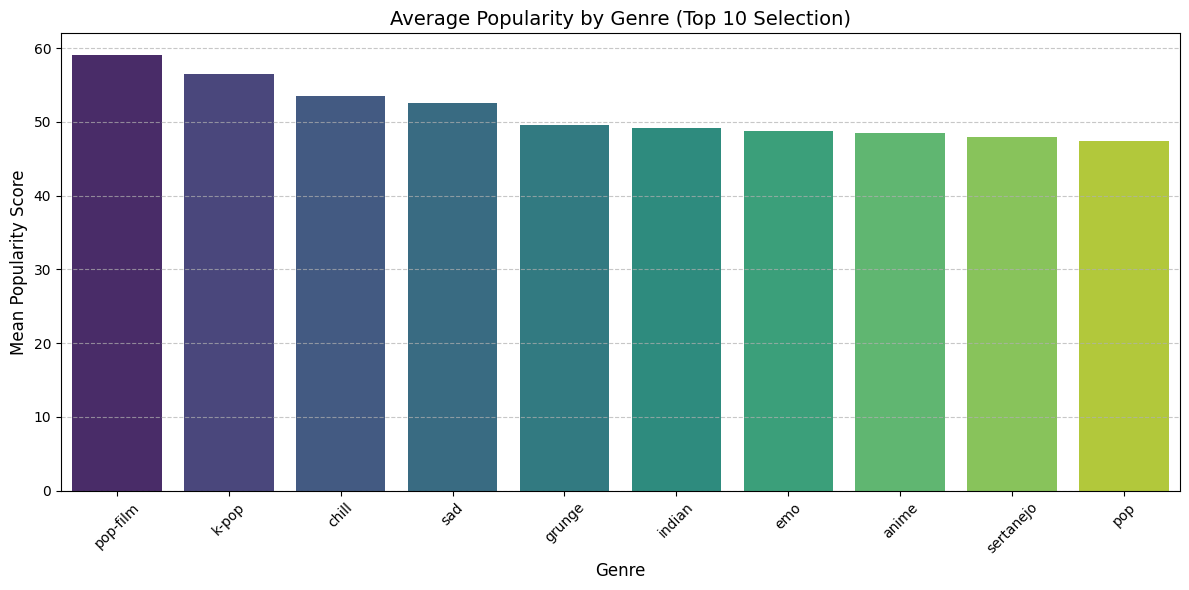

Average Popularity per Genre:
track_genre
pop-film     59.051572
k-pop        56.483503
chill        53.502469
sad          52.531370
grunge       49.603681
indian       49.145244
emo          48.712010
anime        48.464806
sertanejo    47.947368
pop          47.407134
Name: popularity, dtype: float64


In [ ]:
# 1. avg popularity for each genre in your sample
genre_pop_series = df_sample.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=genre_pop_series.index, y=genre_pop_series.values, palette='viridis')

plt.title('Average Popularity by Genre (Top 10 Selection)', fontsize=14)
plt.ylabel('Mean Popularity Score', fontsize=12)
plt.xlabel('Genre', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Display the raw numbers
print("Average Popularity per Genre:")
print(genre_pop_series)

In [ ]:

df_sample = df_sample.reset_index(drop=True)
df_sample.head()

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,is_hit
0,57,120058,1,0.708,0.235,11,-16.156,0,0.3180,0.77200,0.002380,0.1030,0.1690,139.998,4,emo,1
1,4,158391,0,0.869,0.726,11,-5.654,0,0.0459,0.07840,0.000000,0.1070,0.3430,124.023,4,pop,0
2,44,380306,0,0.473,0.858,1,-4.982,0,0.0533,0.00156,0.242000,0.1150,0.0439,124.987,4,grunge,0
3,73,195200,1,0.768,0.374,7,-12.490,1,0.7230,0.28800,0.000002,0.1110,0.3980,75.503,4,chill,1
4,58,264538,0,0.458,0.384,8,-5.045,1,0.0267,0.73400,0.000000,0.0985,0.1570,148.210,3,k-pop,1


## 8. Save the prepared dataset

In [ ]:
df_sample.to_csv('Spotify_Music_top_10_genres.csv', index=False)
print(f'Saved: Spotify_Music_top_10_genres.csv ({df_sample.shape[0]:,} rows × {df_sample.shape[1]} columns)')

Saved: Spotify_Music_top_10_genres.csv (7,999 rows × 17 columns)
